In [1]:
#---IMPORTS---
import torch
from torch import nn
from torch.nn.utils import spectral_norm
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
#---CONFIGS---
torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
IMG_SIZE = 128
IMG_CHANNEL = 1
NOISE_DIM = 100
BATCH_SIZE = 8
EPOCHS = 300
LR = 2e-4
FEATURE_D = 32
FEATURE_G = 32
torch.backends.cudnn.benchmark = True

cuda


In [3]:
#---PIL grayscale + resize---
img = Image.open("photonic_images/GAN_images/fig1_.7217.JPG")
img = img.convert("L")  # grayscale
img = img.resize((128, 128))
arr = np.array(img)

print("Shape:", arr.shape)        # should be (64, 64)
print("Min value:", arr.min())    # darkest pixel
print("Max value:", arr.max())    # brightest pixel  
print("Mean value:", arr.mean())  # average brightness
print("Unique values:", len(np.unique(arr)))  # how many distinct values

Shape: (128, 128)
Min value: 7
Max value: 240
Mean value: 142.661376953125
Unique values: 159


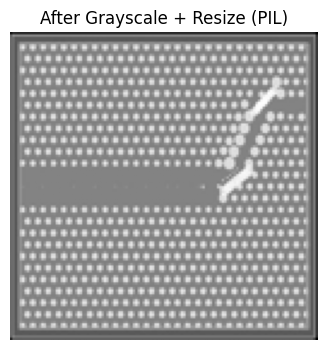

In [4]:
# Visualize after PIL grayscale + resize
plt.figure(figsize=(4,4))
plt.imshow(arr, cmap="gray")
plt.title("After Grayscale + Resize (PIL)")
plt.axis("off")
plt.show()

In [5]:
#---DATASET---
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size= (128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(IMG_CHANNEL)],[0.5 for _ in range(IMG_CHANNEL)])
    ])

dataset = datasets.ImageFolder(root= "photonic_images",
                               transform= transform)

loader = DataLoader(dataset=dataset,
                    batch_size= BATCH_SIZE,
                    shuffle= True,
                    drop_last=True)

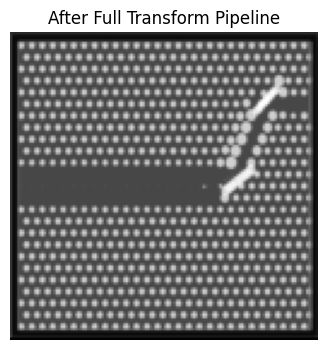

In [6]:
# Visualize after full transform pipeline
imgs, _ = next(iter(loader))
sample = imgs[0].squeeze()
sample = sample * 0.5 + 0.5  # denormalize back to 0-1 for display
plt.figure(figsize=(4,4))
plt.imshow(sample, cmap="gray")
plt.title("After Full Transform Pipeline")
plt.axis("off")
plt.show()

In [7]:
print(f"Length of dataset: {len(dataset)}")
print(f"Number of batches: {len(loader)}")
imgs, labels = next(iter(loader))
print(f"Batch Shape: {imgs.shape}")

Length of dataset: 34
Number of batches: 4
Batch Shape: torch.Size([8, 1, 128, 128])


In [8]:
img, _ = next(iter(loader))
print(img.min())
print(img.max())
print(imgs.mean())

tensor(-0.7804)
tensor(0.8667)
tensor(0.1274)


In [9]:
#---MODELS---
class MinibatchStdDev(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, x):

        std = torch.std(x, dim=0, keepdim=True)

        mean_std = std.mean()

        shape = list(x.shape)

        shape[1] = 1

        std_feature = mean_std.repeat(shape)

        return torch.cat([x, std_feature], dim=1)
    
class Discriminator(nn.Module):
    def __init__(self, IMG_CHANNEL, FEATURE_D):
        super().__init__()

        self.disc = nn.Sequential(

            spectral_norm(nn.Conv2d(
                IMG_CHANNEL,
                FEATURE_D,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )),
            nn.LeakyReLU(0.2, inplace=True),

            self._block(FEATURE_D, FEATURE_D * 2, 4, 2, 1),
            # 32x32

            self._block(FEATURE_D * 2, FEATURE_D * 4, 4, 2, 1),
            # 16x16

            self._block(FEATURE_D * 4, FEATURE_D * 8, 4, 2, 1),
            # 8x8

            self._block(FEATURE_D * 8, FEATURE_D * 16, 4, 2, 1),
            # 4x4

            MinibatchStdDev(),

            spectral_norm(nn.Conv2d(
                FEATURE_D * 16 + 1,
                1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ))
        )

    def _block(self, in_channels, out_channels,
               kernel_size, stride, padding):

        return nn.Sequential(
            spectral_norm(nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False
            )),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.disc(x).reshape(-1)
    
class Generator(nn.Module):
    def __init__(self, NOISE_DIM, IMG_CHANNEL, FEATURE_G):
        super().__init__()

        self.gen = nn.Sequential(

            # Input: N x NOISE_DIM x 1 x 1

            self._block(NOISE_DIM, FEATURE_G * 16, 4, 1, 0),
            # 4x4

            self._block(FEATURE_G * 16, FEATURE_G * 8, 4, 2, 1),
            # 8x8

            self._block(FEATURE_G * 8, FEATURE_G * 4, 4, 2, 1),
            # 16x16

            self._block(FEATURE_G * 4, FEATURE_G * 2, 4, 2, 1),
            # 32x32

            self._block(FEATURE_G * 2, FEATURE_G, 4, 2, 1),
            # 64x64

            nn.ConvTranspose2d(
                FEATURE_G,
                IMG_CHANNEL,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            # 128x128

            nn.Tanh()
        )

    def _block(self, in_channels, out_channels,
               kernel_size, stride, padding):

        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size,
                stride,
                padding,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, x):
        x = x.view(x.shape[0], x.shape[1], 1, 1)
        return self.gen(x)
    

def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def test():

    img_channel, feature_d, H, W = 1, 8, 128, 128
    noise_dim = 100

    real = torch.randn(1, img_channel, H, W)
    noise = torch.randn(2, noise_dim)

    disc = Discriminator(img_channel, feature_d)
    print(f"Disc output shape: {disc(real).shape}")
    assert disc(real).shape == (1,), "Discriminator test failed"

    gen = Generator(
        NOISE_DIM=noise_dim,
        IMG_CHANNEL=img_channel,
        FEATURE_G=8
    )

    print(f"Gen output shape: {gen(noise).shape}")

    assert gen(noise).shape == (
        2,
        img_channel,
        128,
        128
    ), "Generator test failed"

    print("Success, tests passed!")

test()




Disc output shape: torch.Size([1])
Gen output shape: torch.Size([2, 1, 128, 128])
Success, tests passed!


C:\Users\rsdas\AppData\Local\Temp\ipykernel_22848\692700310.py:9: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  std = torch.std(x, dim=0, keepdim=True)


In [10]:
#---TRAINING_SETUP---
disc = Discriminator(IMG_CHANNEL= IMG_CHANNEL, FEATURE_D= FEATURE_D).to(device)

disc.apply(weights_init)

gen = Generator(NOISE_DIM= NOISE_DIM, IMG_CHANNEL= IMG_CHANNEL, FEATURE_G= FEATURE_G).to(device)

gen.apply(weights_init)

disc_optim = optim.Adam(params= disc.parameters(), lr=LR, betas=(0.5, 0.999))
gen_optim = optim.Adam(params= gen.parameters(), lr=LR, betas=(0.5, 0.999))

loss_fn = nn.BCEWithLogitsLoss()

FIXED_NOISE = torch.randn(36, NOISE_DIM).to(device)

writer_fake = SummaryWriter(log_dir= "logs/fake")
writer_real = SummaryWriter(log_dir= "logs/real")

step = 0

In [11]:
real, _ = next(iter(loader))
real = real.to(device)
print(f"Img Shape: {real.shape}")

noise = torch.randn(BATCH_SIZE, NOISE_DIM).to(device)
print(f"Noise Shape: {noise.shape}")

fake = gen(noise)

real_D = disc(real)
print(f"real_D Shape: {real_D.shape}")

fake_D = disc(fake)
print(f"fake_D Shape: {fake_D.shape}")


Img Shape: torch.Size([8, 1, 128, 128])
Noise Shape: torch.Size([8, 100])
real_D Shape: torch.Size([8])
fake_D Shape: torch.Size([8])


In [12]:
#---TRAINING_LOOP---
for epoch in range(EPOCHS):
    for batch, (real, _) in enumerate(loader):

        real = real.to(device)
        #real = real + 0.02 * torch.randn_like(real)
        #real = torch.clamp(real, -1, 1)
        noise = torch.randn(real.shape[0], NOISE_DIM).to(device)
        fake = gen(noise)

    # Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        real_D = disc(real)
        real_D_loss = loss_fn(real_D, 0.9 * torch.ones_like(real_D))

        fake_D = disc(fake.detach())
        fake_D_loss = loss_fn(fake_D, torch.zeros_like(fake_D))

        lossD = (real_D_loss + fake_D_loss) / 2

        disc_optim.zero_grad()

        lossD.backward()

        disc_optim.step()

    # Train Generator: max log(D(G(z)))
        output = disc(fake)
        lossG = loss_fn(output, torch.ones_like(output))

        gen_optim.zero_grad()

        lossG.backward()

        gen_optim.step()

    if epoch % 10 == 0:
            print(f"EPOCH: {epoch}/{EPOCHS} | LOSS_D: {lossD.item():.4f} | LOSS_G: {lossG.item():.4f}")
              
            with torch.no_grad():
                 gen.eval()
                 fake_display = gen(FIXED_NOISE)
                 gen.train()

                 real_display = real.reshape(-1, 1, IMG_SIZE, IMG_SIZE)
                 

                 img_grid_fake = torchvision.utils.make_grid(fake_display, normalize=True)
                 img_grid_real = torchvision.utils.make_grid(real_display, normalize=True)

                 writer_fake.add_image("Photonic Fake", img_grid_fake, global_step=step)
                 writer_real.add_image("Photonic Real", img_grid_real, global_step=step)
                 
                 step += 1


EPOCH: 0/300 | LOSS_D: 0.5215 | LOSS_G: 0.8981
EPOCH: 10/300 | LOSS_D: 0.2924 | LOSS_G: 1.9960
EPOCH: 20/300 | LOSS_D: 0.3926 | LOSS_G: 1.1386
EPOCH: 30/300 | LOSS_D: 0.5422 | LOSS_G: 0.8306
EPOCH: 40/300 | LOSS_D: 0.5098 | LOSS_G: 0.6938
EPOCH: 50/300 | LOSS_D: 0.4276 | LOSS_G: 1.0005
EPOCH: 60/300 | LOSS_D: 0.4651 | LOSS_G: 0.9252
EPOCH: 70/300 | LOSS_D: 0.8050 | LOSS_G: 0.5657
EPOCH: 80/300 | LOSS_D: 0.5899 | LOSS_G: 0.4738
EPOCH: 90/300 | LOSS_D: 0.6043 | LOSS_G: 0.6213
EPOCH: 100/300 | LOSS_D: 0.5898 | LOSS_G: 0.8814
EPOCH: 110/300 | LOSS_D: 0.7385 | LOSS_G: 0.5011
EPOCH: 120/300 | LOSS_D: 0.7825 | LOSS_G: 0.6145
EPOCH: 130/300 | LOSS_D: 0.6559 | LOSS_G: 0.5798
EPOCH: 140/300 | LOSS_D: 0.6158 | LOSS_G: 0.6552
EPOCH: 150/300 | LOSS_D: 0.5214 | LOSS_G: 1.2166
EPOCH: 160/300 | LOSS_D: 0.4951 | LOSS_G: 0.9885
EPOCH: 170/300 | LOSS_D: 0.6078 | LOSS_G: 0.6840
EPOCH: 180/300 | LOSS_D: 0.5813 | LOSS_G: 0.7464
EPOCH: 190/300 | LOSS_D: 0.6037 | LOSS_G: 0.8123
EPOCH: 200/300 | LOSS_D: 0.6376

In [13]:
with torch.no_grad():
    gen.eval()
    import os
    os.makedirs("generated_samples", exist_ok=True)
    
    for i in range(200):
        noise = torch.randn(1, NOISE_DIM).to(device)
        img = gen(noise).squeeze().cpu()
        img = img * 0.5 + 0.5
        img = img.clamp(0, 1)
        plt.imsave(f"generated_samples/generated_{i+1}.png", img.numpy(), cmap="gray")
    
    gen.train()
    print("Saved 200 grayscale images to generated_samples/")

Saved 200 grayscale images to generated_samples/


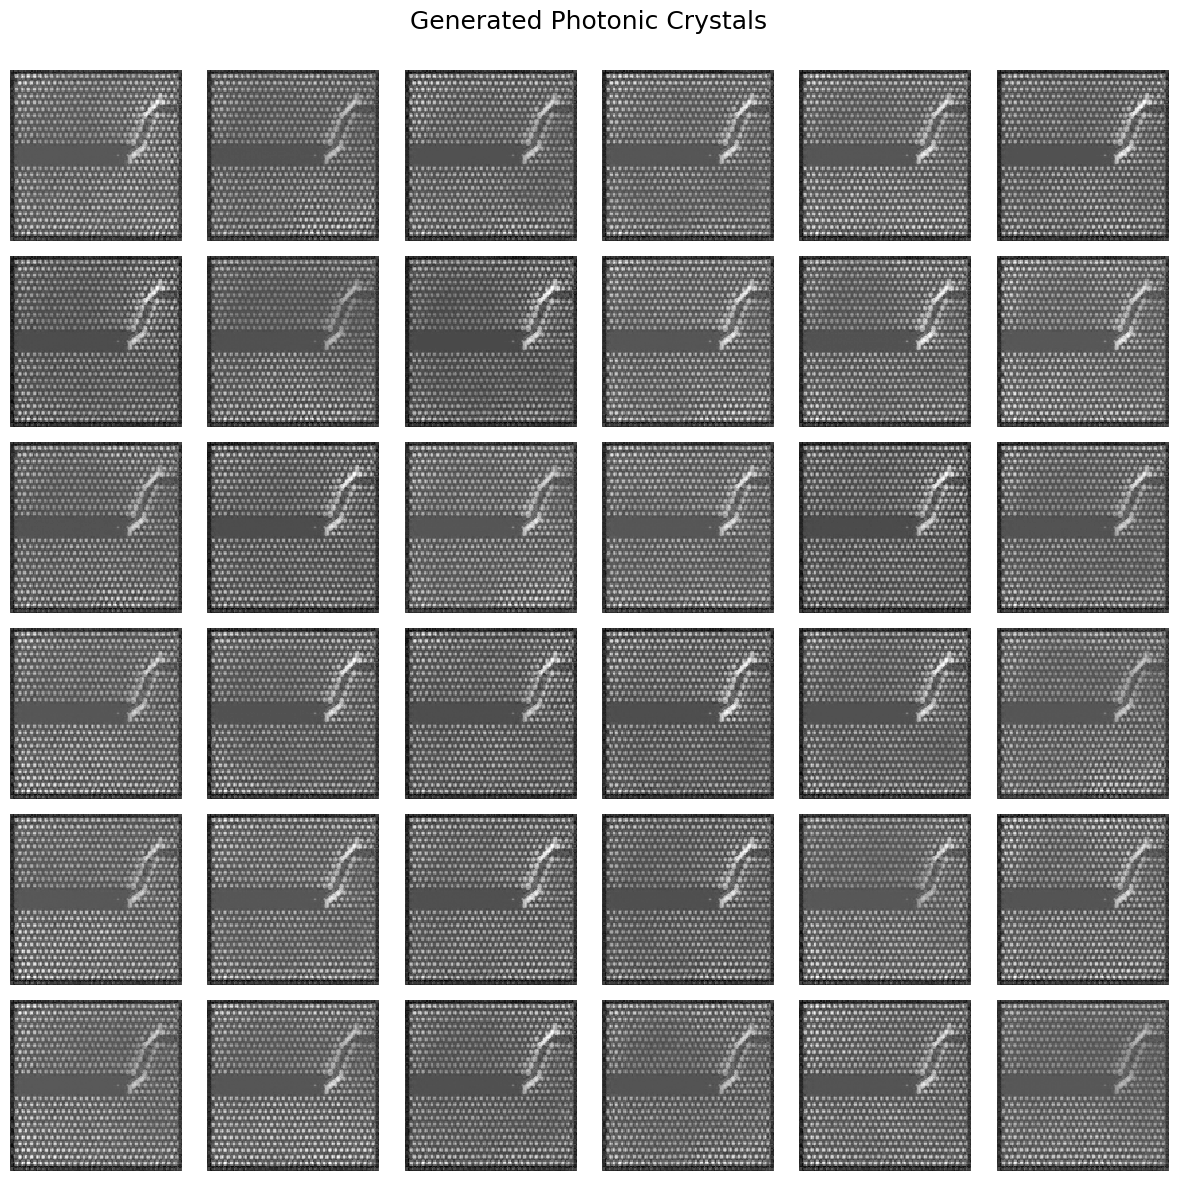

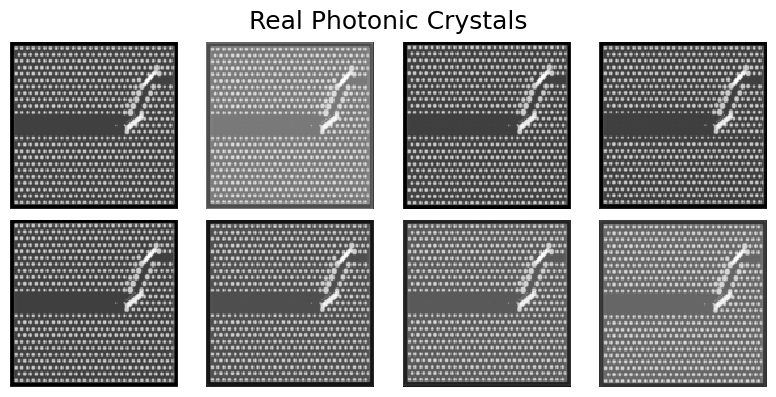

In [14]:
#---VISUALIZATION---

import math

# =========================
# GENERATED IMAGES
# =========================

with torch.no_grad():
    gen.eval()
    sample = gen(FIXED_NOISE).cpu()
    gen.train()

sample_raw = (sample * 0.5 + 0.5).clamp(0, 1)

num_images = sample_raw.shape[0]

cols = 6
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 2, rows * 2)
)

axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):

    if i < num_images:

        ax.imshow(
            sample_raw[i].squeeze(),
            cmap="gray",
            interpolation="nearest"
        )

    ax.axis("off")

plt.suptitle(
    "Generated Photonic Crystals",
    fontsize=18
)

plt.tight_layout()
plt.subplots_adjust(top=0.93)

plt.show()


# =========================
# REAL IMAGES
# =========================

real_batch, _ = next(iter(loader))

real_raw = (real_batch * 0.5 + 0.5).clamp(0, 1)

num_real = real_raw.shape[0]

cols = 4
rows = math.ceil(num_real / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 2, rows * 2)
)

axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):

    if i < num_real:

        ax.imshow(
            real_raw[i].squeeze(),
            cmap="gray",
            interpolation="nearest"
        )

    ax.axis("off")

plt.suptitle(
    "Real Photonic Crystals",
    fontsize=18
)

plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()